In [6]:
import numpy as np
import matplotlib.pyplot as plt

#class +1
X_pos = np.array([[2,3], [3,4], [4,5], [5,6]])

# Class -1
X_neg = np.array([[1,1], [2,1], [2,2], [3,1]])

X = np.vstack((X_pos, X_neg))
y = np.array([1]*len(X_pos) + [-1]*len(X_neg))

print(X)
print(y)

[[2 3]
 [3 4]
 [4 5]
 [5 6]
 [1 1]
 [2 1]
 [2 2]
 [3 1]]
[ 1  1  1  1 -1 -1 -1 -1]


In [7]:
def activation(y_in, theta=0):
    if y_in > theta:
        return 1
    elif y_in < -theta:
        return -1
    else:
        return 0 

In [8]:
w = np.random.randn(2)
b = np.random.randn()
lr = 0.1
epochs = 20

for epoch in range(epochs):
    for i in range(len(X)):
        y_in = np.dot(w, X[i]) + b
        y_pred = activation(y_in)

        #
        if y_pred != y[i]:
            w = w + lr * y[i] * X[i]
            b = b + lr * y[i]

print("Final Weights:", w)
print("Final Bias:", b)


Final Weights: [-0.42698447  0.52848275]
Final Bias: -0.2135827677455671


[[0.         0.03517588 0.07035176 ... 6.92964824 6.96482412 7.        ]
 [0.         0.03517588 0.07035176 ... 6.92964824 6.96482412 7.        ]
 [0.         0.03517588 0.07035176 ... 6.92964824 6.96482412 7.        ]
 ...
 [0.         0.03517588 0.07035176 ... 6.92964824 6.96482412 7.        ]
 [0.         0.03517588 0.07035176 ... 6.92964824 6.96482412 7.        ]
 [0.         0.03517588 0.07035176 ... 6.92964824 6.96482412 7.        ]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.03517588 0.03517588 0.03517588 ... 0.03517588 0.03517588 0.03517588]
 [0.07035176 0.07035176 0.07035176 ... 0.07035176 0.07035176 0.07035176]
 ...
 [6.92964824 6.92964824 6.92964824 ... 6.92964824 6.92964824 6.92964824]
 [6.96482412 6.96482412 6.96482412 ... 6.96482412 6.96482412 6.96482412]
 [7.         7.         7.         ... 7.         7.         7.        ]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0.

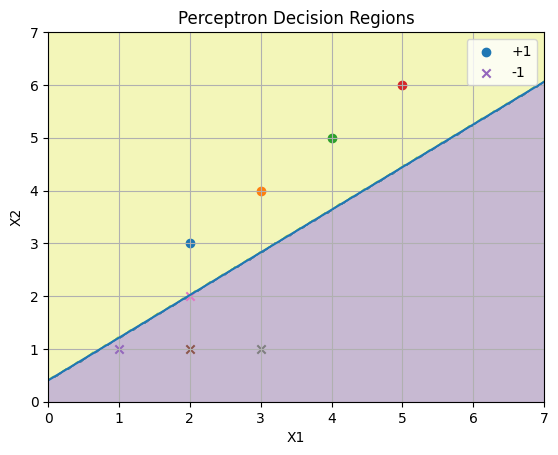

In [11]:
x_min, x_max = 0, 7
y_min, y_max = 0, 7

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = np.zeros(xx.shape)
print(xx)

print(yy)

print(Z)

# Classify each grid point
for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        point = np.array([xx[i,j], yy[i,j]])
        y_in = np.dot(w, point) + b
        Z[i,j] = activation(y_in)

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training points
for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i][0], X[i][1], marker='o', label='+1' if i==0 else "")
    else:
        plt.scatter(X[i][0], X[i][1], marker='x', label='-1' if i==len(X_pos) else "")

# Decision boundary line
x_vals = np.linspace(0,7,100)
y_vals = -(w[0]*x_vals + b) / w[1]
plt.plot(x_vals, y_vals)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Perceptron Decision Regions")
plt.legend()
plt.grid()

plt.show()